# Plots for UMAP annotation

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data

# dataframes
import pandas as pd
import numpy as np
# Micellaneous utilities
import warnings              # Suppress or manage warnings

# Data visualization
import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting interface
import matplotlib            # Base matplotlib functionality
from matplotlib.backends.backend_pdf import PdfPages  # Save plots to multi-page PDFs

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import misc as mi

#### Define saving paths

In [2]:
# Paths
base_dir = str(here('data/annotate/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
diffg_dir = os.path.join(base_dir, 'dg_onevsother') 

anndata_dir = str(here('data/anndata/'))

#### Load

In [3]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AH_combined.h5ad"))

#### Marker genes to plot

In [4]:
#"endothelial": ["PECAM1", "PLVAP", "FLT1"],
markers = {
    "acinar": ["PRSS1", "PRSS2", "CPA1"],
    "acinar_reg_plus": ["REG3A", "REG3G", "REG1B"],
    "alpha": ["GCG", "TTR", "MAFB"],
    "beta": ["INS", "IAPP", "MAFA"],
    "cycling": ["TOP2A", "MKI67", "CCNB1"],
    "delta": ["SST", "HHEX", "LY6H"],
    "ductal": ["KRT19", "CFTR", "HNF1B"],
    "ductal_mucin": ["MUC1", "TFF1", "TFF2"],
    "endmt": ["COL3A1", "DDR2", "HIF1A"],
    "endothelial_islet": ["PASK", "ESM1", "LAMA4"],
    "epsilon": ["GHRL", "PHGR1", "RBP4"],
    "gamma": ["PPY", "ARX", "ETV1"],
    "mast": ["S100A4", "RGS10", "LTC4S"],
    "myeloid": ["LYZ", "HLA-DRA", "CD68"],
    "schwann" : ["CRYAB", "S100B", "PMP22"],
    "stellate_a": ["TIMP1", "COL1A2", "VCAN"],
    "stellate_q": ["RGS5", "FABP4", "ADIRF"]
}

gene_order = ['beta', 'alpha', 'delta', 'gamma', 'epsilon', 'cycling', 
              'endothelial_islet', 'endmt', 'stellate_a', 'stellate_q',
                 'mast', 'myeloid', 'schwann', 'acinar', 'acinar_reg_plus', 'ductal', 'ductal_mucin']

markers = {k: markers[k] for k in gene_order}

marker_genes = []
for cell, x in markers.items():
    marker_genes += x

In [54]:
len(marker_genes)

51

#### Mean counts per cell type

In [5]:
# get normalized counts, mean, variance and z-score
genedf = sc.get.obs_df(adata, keys=["manual_annotation", *marker_genes])
grouped = genedf.groupby("manual_annotation", observed=True)
mean, var = grouped.mean(), grouped.var()
z = (mean - mean.mean(axis=0)) / mean.std(axis=0)

In [6]:
celltype_order = ['beta', 'alpha', 'delta', 'gamma', 'epsilon', 'cycling', 
                  'endothelial_islet', 'endmt_early', 'endmt_late', 'stellate_activated', 'stellate_quiescent',
                 'mast', 'myeloid', 'schwann', 'acinar', 'acinar_reg_plus', 'ductal', 'ductal_mucin']

z = z.loc[celltype_order]

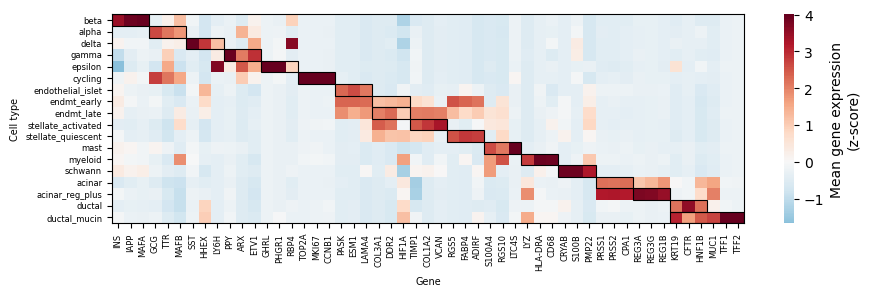

In [8]:
plt.figure(figsize=(z.shape[1] * 0.2, z.shape[0] * 0.2))
from matplotlib import patches
ax = sns.heatmap(
    z,
    cmap='RdBu_r',
    center=0,
    cbar_kws={"label": "Mean gene expression\n(z-score)"}
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("black")

ax.set_xticks(range(len(z.columns)))
ax.set_xticks(np.arange(len(z.columns)) + 0.5)
ax.set_xticklabels(z.columns, fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, color="black")

ax.set_xlabel("Gene", fontsize=7)
ax.set_ylabel("Cell type", fontsize=7)

groups = [
    (0, 3),   
    (3, 3),   
    (6, 3),  
    (9, 3), 
    (12, 3), 
    (15, 3), 
    (18, 3), 
    (21, 3),
    (21, 3),
    (24, 3), 
    (27, 3), 
    (30, 3), 
    (33, 3), 
    (36, 3), 
    (39, 3),
    (42,3),
    (45, 3),
    (45, 6), 
]

for row, (col_start, width) in enumerate(groups):
    rect = patches.Rectangle(
        (col_start, row),
        width,
        1,
        fill=False,
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_patch(rect)

plt.subplots_adjust(bottom=0.3)
plt.savefig(os.path.join(plot_dir, "marker_genes_heatmap.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [9]:
adata

AnnData object with n_obs × n_vars = 502863 × 60656
    obs: 'name', 'sample', 'cell_nuclei', 'library_prep', 'platform', 'rna_count', 'n_feature', 'mitochondrial_fraction', 'coding_fraction', 'contrast_fraction', 'complexity', 'uniquely_mapped_reads_percent', 'unmapped_reads_percent', 'excluded', 'ic_id_dataset', 'ic_id_dataset_donor', 'ic_id_sample', 'study', 'donor', 'pmid', 'doi', 'year_public', 'disease', 'age_years', 'tissue', 'islet_center', 'library_layout', 'instrument_seq', 'strandedness', 'type_of_alignment', 'star_version', 'count_quantification', 'count_molecule', 'study_cell_annotation_harmonized', 'n_count', 'ic_id_donor_integrate', 'bioproject', 'geo_accession', 'identifier', 'gender', 'bmi', 'ethnicity', 'islet_culture_medium', 'islet_culture_medium_glucose_milimolar', 'study_cell_annotation', 'dissociation_method', 'dissociation_tool', 'ethnicity_broad_harmonized', 'ethnicity_sub_harmonized', 'disease_harmonized', 'n_umi', 'sex', 'islet_culture_hours', 'islet_isolatio

#### Plot UMAP

In [133]:
sc.pl.umap(
    adata,
    color='manual_annotation',
    legend_fontsize=5,
    size=1,
    show=False  
)

ax = plt.gca()

# Remove border
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Rasterize points
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig(
    os.path.join(plot_dir, "umap_manual_annotation.pdf"),
    bbox_inches="tight", 
    dpi=300
)
plt.close()

#### Overview of data and donors

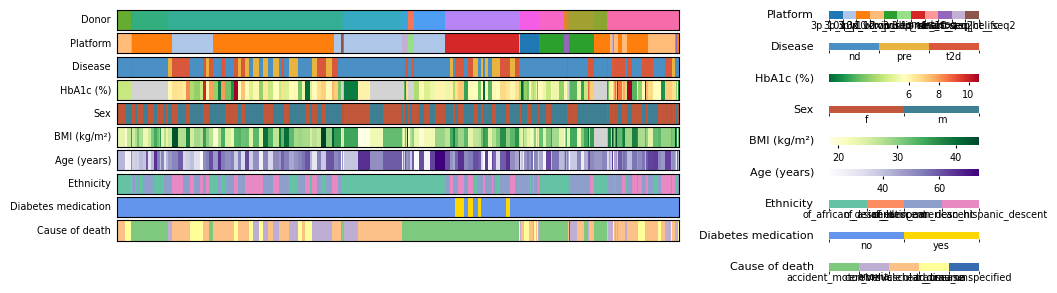

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colors
from copy import copy
import seaborn as sns
import os

obs = adata.obs

# -------------------------
# 1. Annotation data + labels
# -------------------------
data = {
    "Donor": pd.Categorical(obs["ic_id_study"]),
    # "Dataset": pd.Categorical(obs["ic_id_dataset"]),
    # "Donor": pd.Categorical(obs["ic_id_donor_overall"]),
    "Platform": pd.Categorical(obs["library_prep"]),
    "Disease": pd.Categorical(obs["disease_harmonized"]),
    "HbA1c (%)": obs["hba_1_c_percent"].values,
    "Sex": pd.Categorical(obs["sex_predicted"]),
    "BMI (kg/m²)": obs["bmi"].values,
    "Age (years)": obs["age_years"].values,
    "Ethnicity":pd.Categorical(obs["ethnicity_broad_harmonized"]),
    "Diabetes medication": pd.Categorical(obs["diabetes_medication_harmonized"]),
    "Cause of death": pd.Categorical(obs["cause_of_death_broad_harmonized"])
}

# Keep category labels + convert to codes
cat_labels = {}
for k, v in data.items():
    if isinstance(v, pd.Categorical):
        cat_labels[k] = v.categories
        data[k] = v.codes

# -------------------------
# 2. Ordering
# -------------------------
order = np.lexsort((
    obs["hba_1_c_percent"].values,
    obs["ic_id_donor_overall"].astype(str),
    obs["ic_id_study"].astype(str)
))

for k in data:
    data[k] = data[k][order]

# -------------------------
# 3. Colormaps
# -------------------------
n_studies = len(cat_labels["Donor"])
study_colors = sns.color_palette("husl", n_studies)

cmaps = {
    "Donor": ListedColormap(study_colors),
    "Platform": "tab20",
    "Disease": ListedColormap(["#4B90C5", "#E8B43F", "#D9583B"]),
    "HbA1c (%)": "RdYlGn_r",
    "Sex": ListedColormap(["#C2563A", "#3F7F93"]),
    "BMI (kg/m²)": "YlGn",
    "Age (years)": "Purples",
    "Diabetes medication": ListedColormap(["cornflowerblue", "gold"]),
    "Ethnicity": "Set2",
    "Cause of death": "Accent"
}

# NaN color for continuous
for key in ["HbA1c (%)", "BMI (kg/m²)", "Age (years)"]:
    cmap = copy(plt.get_cmap(cmaps[key]))
    cmap.set_bad("lightgrey")
    cmaps[key] = cmap

# -------------------------
# 4. Plot
# -------------------------
fig, axes = plt.subplots(len(data), 1, figsize=(15, 3), sharex=True)

continuous_vars = ["HbA1c (%)", "BMI (kg/m²)", "Age (years)"]
mappables = {}

for ax, (label, values) in zip(axes, data.items()):

    if label in continuous_vars:
        masked = np.ma.masked_invalid(values)
    
        if label == "HbA1c (%)":
            norm = TwoSlopeNorm(
                vmin=np.nanpercentile(values, 1),
                vcenter=5.7,
                vmax=np.nanpercentile(values, 99)
            )
        else:
            norm = colors.Normalize(
                vmin=np.nanpercentile(values, 1),
                vmax=np.nanpercentile(values, 99)
            )

    else:
        # categorical normalization
        n_cat = len(cat_labels[label])
        norm = colors.BoundaryNorm(np.arange(-0.5, n_cat + 0.5), n_cat)

    im = ax.imshow(
        values[np.newaxis, :],
        aspect='auto',
        cmap=cmaps[label],
        norm=norm,
        interpolation='nearest'
    )

    mappables[label] = im

    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=7)
    ax.set_xticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

plt.subplots_adjust(right=0.5, hspace=0.15)

# -------------------------
# 5. Compact legend-style colorbars
# -------------------------
legend_x = 0.6
legend_width = 0.1
legend_height = 0.025
gap = 0.08

labels = [k for k in data.keys() if k not in ["Donor", "Dataset", "Study"]]

for i, label in enumerate(labels):
    y = 0.85 - i * (legend_height + gap)

    cax = fig.add_axes([
        legend_x,
        y,
        legend_width,
        legend_height
    ])

    im = mappables[label]

    cbar = fig.colorbar(
        im,
        cax=cax,
        orientation='horizontal'
    )

    if label in continuous_vars:
        # clean numeric ticks
        cbar.ax.tick_params(labelsize=7, length=2)
    else:
        cats = cat_labels[label]

        cbar.set_ticks(range(len(cats)))
        cbar.set_ticklabels(cats)

        # make it compact like your example
        cbar.ax.tick_params(
            labelsize=7,
            length=0,
            pad=1
        )

    # remove frame for cleaner look
    cbar.outline.set_visible(False)

    # label on the LEFT (like your figure)
    fig.text(
        legend_x - 0.01,
        y + legend_height / 2,
        label,
        ha='right',
        va='center',
        fontsize=8
    )

# -------------------------
# 6. Save
# -------------------------
plt.savefig(
    os.path.join(plot_dir, "annotation_bars.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Plotting meta data

In [221]:
summary = pd.DataFrame({
    "N": [
        adata.obs["ic_id_study"].nunique(),
        adata.obs["ic_id_dataset"].nunique(),
        adata.obs["ic_id_donor_overall"].nunique(),
        adata.obs["ic_id_platform_adjusted_sample"].nunique(),
        adata.obs["library_prep"].nunique(),
        adata.obs["manual_annotation"].nunique(),
        len(adata.obs.index)
    ]
}, index = [
        "Studies",
        "Datasets",
        "Unique donors",
        "Samples",
        "Platforms",
    "Cell types",
    "Cells"
    ])



print(summary)

                    N
Studies            22
Datasets           25
Unique donors     270
Samples           333
Platforms          11
Cell types         18
Cells          502863


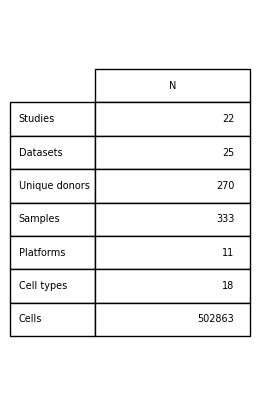

In [230]:
fig, ax = plt.subplots(figsize = (2,5))

ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 2)

plt.show()